# Clustering con K-Means: Wine Dataset (UCI)

## Objetivo
Aplicar **clustering (agrupación)** usando **K-Means** sobre el dataset **Wine (UCI ID: 109)** para encontrar grupos naturales en los datos, justificar el número de clusters y analizar los resultados.

## Técnica elegida: Clustering (K-Means)
K-Means es un algoritmo no supervisado que busca particionar los datos en **K grupos**, minimizando la distancia de cada punto a su centroide (inercia).
En este notebook:
- Cargamos y exploramos el dataset
- Preprocesamos (limpieza y escalado)
- Elegimos K con **método del codo** y **silhouette**
- Entrenamos K-Means final
- Visualizamos y analizamos resultados


In [2]:
pip install ucimlrepo

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [25]:
# Cargar Wine dataset desde UCI
wine = fetch_ucirepo(id=109)

# Features (X) y target (y)
X = wine.data.features
y = wine.data.targets

print("Dimensiones X:", X.shape)
print("Dimensiones y:", y.shape)

Dimensiones X: (178, 13)
Dimensiones y: (178, 1)


In [26]:
# Vista rápida de los datos
display(X.head())
display(y.head())

print("X shape:", X.shape)
print("y shape:", y.shape)

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


,class
0,1
1,1
2,1
3,1
4,1


X shape: (178, 13)
y shape: (178, 1)


In [27]:
# Estructura de datos
print("INFO DE X")
print(X.info())

# Valores faltantes
print("\nNaN por columna (X):")
print(X.isna().sum())

INFO DE X
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malicacid                     178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  0D280_0D315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  


In [29]:
target_col = y.columns[0]

# DataFrame auxiliar para análisis (la clase real NO se usa para entrenar)
datos = X.copy()
datos["Clase_real"] = y[target_col].to_numpy()

datos.head()

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,Clase_real
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [30]:
# Escalado necesario porque K-Means se basa en distancias euclidianas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape:", X_scaled.shape)

X_scaled shape: (178, 13)


In [33]:
# Iteramos sobre distintos valores de K, creamos un modelo con K clusters, y calculamos las inercias
inertias = []
K_range = range(2, 11)

for k in K_range:
    print("Ejecutando con K =", k)
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

Ejecutando con K = 2
Ejecutando con K = 3
Ejecutando con K = 4
Ejecutando con K = 5
Ejecutando con K = 6
Ejecutando con K = 7
Ejecutando con K = 8
Ejecutando con K = 9
Ejecutando con K = 10


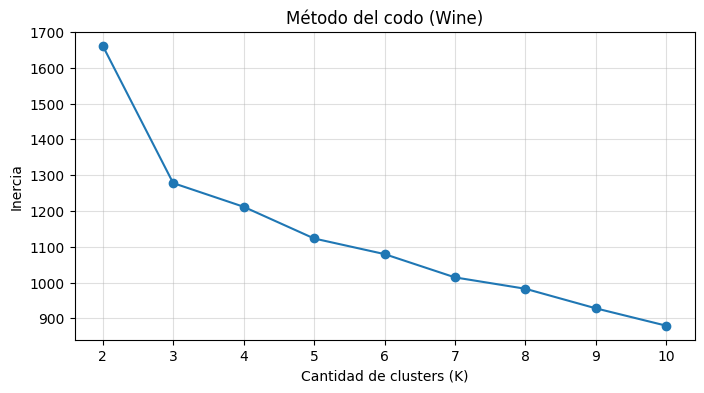

In [34]:
# Visualizacion del metodo del codo
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Método del codo (Wine)")
plt.xlabel("Cantidad de clusters (K)")
plt.ylabel("Inercia")
plt.grid(True, alpha=0.4)
plt.show()

## Interpretación del método del codo
Se observa el punto donde la disminución de la inercia comienza a ser menos pronunciada.
Ese valor de K representa un buen compromiso entre simplicidad y ajuste del modelo.

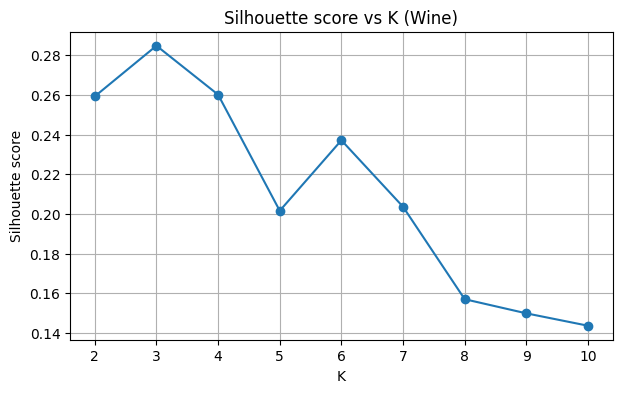

Mejor K según silhouette: 3


In [35]:
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), sil_scores, marker="o")
plt.title("Silhouette score vs K (Wine)")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.grid(True, alpha=0.4)
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print("Mejor K según silhouette:", best_k)


## Elección de K
El valor de K se selecciona considerando:
- El punto de codo en la gráfica de inercia.
- El mayor valor del silhouette score.

Se elige un K que esté respaldado por ambas métricas.

In [36]:
K_final = best_k

modelo = KMeans(n_clusters=K_final, random_state=42)
clusters = modelo.fit_predict(X_scaled)

datos["Cluster"] = clusters

print("K_final:", K_final)
print("Cantidad de elementos por cluster:")
print(datos["Cluster"].value_counts().sort_index())

print("Silhouette final:", silhouette_score(X_scaled, clusters))

K_final: 3
Cantidad de elementos por cluster:
Cluster
0    65
1    51
2    62
Name: count, dtype: int64
Silhouette final: 0.2848589191898987


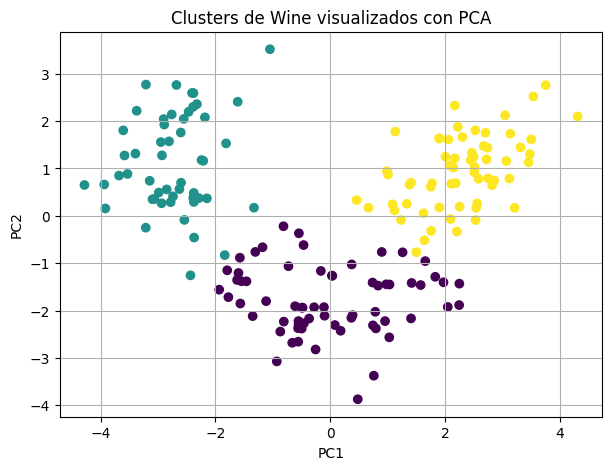

Varianza explicada total (PC1 + PC2): 0.5540633835693527


In [37]:
# Visualizacion de clusters

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters)
plt.title("Clusters de Wine visualizados con PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

var = pca.explained_variance_ratio_
print("Varianza explicada total (PC1 + PC2):", var.sum())

In [38]:
display(datos.groupby("Cluster").mean(numeric_only=True))

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,Clase_real
Cluster,,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231,2.000000
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824,2.941176
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806,1.048387


In [39]:
display(pd.crosstab(datos["Clase_real"], datos["Cluster"]))

Cluster,0,1,2
Clase_real,,,
1,0,0,59
2,65,3,3
3,0,48,0


## Conclusiones
- K-Means permitió identificar grupos de vinos con características químicas similares.
- El escalado fue esencial para evitar sesgo por magnitudes distintas.
- El valor de K fue justificado mediante el método del codo y el silhouette score.
- PCA facilitó la visualización de los clusters en dos dimensiones.
- La clase real se utilizó únicamente para análisis posterior y no para entrenar el modelo.